In [1]:
%load_ext autoreload 
%autoreload 2

from kf import KalmanFilter

import jax.numpy as jnp
from jax.random import multivariate_normal, key
from jax import Array

rng = key(123)

$$
x_t = Ax_{t-1} + q_t
$$

$$
y_t = Hy_{t-1} + r_k
$$

In [315]:
def generate(steps: int, latent_dim: int, obs_dim: int,
            A: Array, B: Array, latent_cov: Array, obs_cov: Array) -> (Array, Array):

    z = jnp.zeros(latent_dim)
    states = []

    latent_mean = jnp.zeros(latent_dim)
    latent_noise = multivariate_normal(rng, mean=latent_mean, cov=latent_cov, shape=(steps,), method='svd')

    obs_mean = jnp.zeros(obs_dim)
    obs_noise = multivariate_normal(rng, mean=obs_mean, cov=obs_cov, shape=(steps,), method='svd')

    for i in range(0, steps):
        z = A @ z + latent_noise[i]
        states.append(z)
    states = jnp.stack(states)
    observations = states + obs_noise
    
    return states, observations
    

In [326]:
steps = 30
latent_dim = 2
obs_dim = 2
step_size = 0.01
transition_matrix = jnp.eye(latent_dim)
observation_matrix = jnp.eye(obs_dim)

rho = 0.999
latent_cov = jnp.array([[1.0, rho], [rho, 1.0]])

sigma_obs = 1e-4
obs_cov = sigma_obs * jnp.diag(jnp.ones(obs_dim))

states, obs = generate(steps, latent_dim, obs_dim, transition_matrix, observation_matrix, latent_cov, obs_cov)

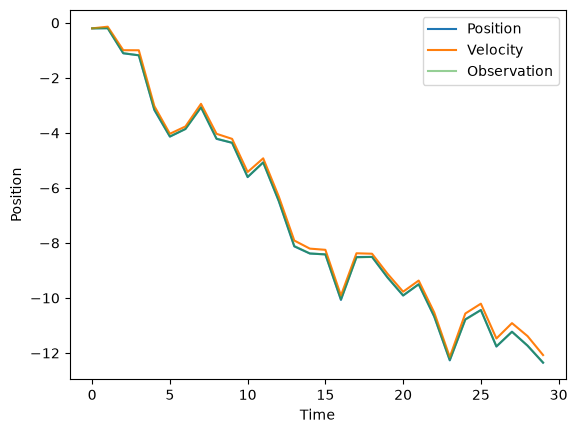

In [327]:
import matplotlib.pyplot as plt

plt.plot(jnp.arange(steps), states[:, 0], label='Position')
plt.plot(jnp.arange(steps), states[:, 1], label='Velocity')
plt.plot(jnp.arange(steps), obs[:, 0], label='Observation', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.show()

In [328]:
m_0 = jnp.zeros(latent_dim)
P_0 = jnp.eye(latent_dim)

In [329]:
m, P = KalmanFilter.filter(m_0, P_0, transition_matrix, observation_matrix, latent_cov, obs_cov, obs)

assert jnp.isnan(m).any() == True
assert jnp.isnan(P).any() == True

print("Number of NaNs in m:", jnp.isnan(m).sum())
print("Number of NaNs in P:", jnp.isnan(P).sum())

Number of NaNs in m: 28
Number of NaNs in P: 56


In [330]:
m, P = KalmanFilter.filter(m_0, P_0, transition_matrix, observation_matrix, latent_cov, obs_cov, obs, use_inv=True)

print("Number of NaNs in m:", jnp.isnan(m).sum())
print("Number of NaNs in P:", jnp.isnan(P).sum())

Number of NaNs in m: 0
Number of NaNs in P: 0
